# Ocean Stratification & Mixed Layer Depth

*Developed starting from an educational activity by Kris Karnauskas at University of Colorado Boulder;
used in courses such as ATOC 1060: Our Changing Environment.*

This notebook uses live Argo float data to explore how the ocean's mixed layer depth (MLD) varies with latitude across different ocean basins.

This notebook uses the Argovis web app and database. Argovis provides an API that indexes and distributes numerous oceanographic datasets with detailed query parameters, enabling you to search and download only and exactly the data of interest.

**How to cite:** If you use this notebook, please cite Sala, J., Giglio, D., Mills, K., & Scanderbeg, M. (2026). *argovis/demo_notebooks* (v0.1.0) [Software]. Zenodo. [https://doi.org/10.5281/zenodo.22032966](https://doi.org/10.5281/zenodo.22032966)

## Notebook structure

- **Part 1** — select three Argo floats in one ocean basin and estimate their mixed layer depth (MLD) from temperature and potential density profiles.
- **Part 2** — repeat the analysis for a second ocean basin and compare results.
- **Student Work** — guided questions throughout.

## Learning Goals

By the end of this activity, you will be able to:

1. **Query and map Argo float profiles** — retrieve temperature, salinity, and pressure profiles using the Argovis API, estimate potential density, and visualize float locations on a map as well as the profiles.
2. **Estimate mixed layer depth visually** — identify MLD$_T$ and MLD$_{PD}$ from temperature and potential density profiles.
3. **Explain why MLD$_T$ and MLD$_{PD}$ differ** — relate differences to near-surface salinity gradients, including freshwater input from sea ice melt or rainfall.
4. **Describe how MLD varies with latitude** — compare deep winter mixing in the Southern Ocean to shallow tropical stratification.
5. **Compare MLD across ocean basins** — repeat the analysis in a second basin at similar latitudes and interpret any differences.

---

**Background:** The *mixed layer* is the uppermost layer of the ocean where turbulent mixing (driven by wind and surface cooling) keeps temperature and salinity roughly uniform with depth. The *mixed layer depth (MLD)* is the depth at which this uniformity breaks down.

We can estimate the MLD in two ways:
- **MLD$_T$**: the depth at which temperature drops noticeably below its surface value
- **MLD$_{PD}$**: the depth at which potential density increases noticeably above its surface value

These two estimates are not always the same — and the reason *why* they differ is one of the key questions in this activity.

## Setup: register an API key

In order to allocate Argovis's limited computing resources fairly, users are encouraged to register and request a free API key. This works like a password that identifies your requests to Argovis.

1. Visit [https://argovis-keygen.colorado.edu/](https://argovis-keygen.colorado.edu/)
2. Fill out the form under **New Account Registration**
3. An API key will be emailed to you shortly

Treat your API key like a password — don't share it or leave it anywhere public. If you ever forget it or accidentally reveal it, visit the same website to change or deactivate your token.

Set `APIKEY` in the cell below before running anything else. The notebook may still work with `'guest'` but may return errors under heavy load.

## Setup: import libraries and functions

The cells below import all required scientific libraries and the notebook helper functions from `notebook_helpers/`. Run them in order before anything else.

In [1]:
# ── Imports — run this cell first, do not modify ─────────────────────────────

from argovisHelpers import helpers as avh
from argovisHelpers import analysis as ava
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import numpy as np
import gsw
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

APIKEY  = 'guest'  # ← paste your key here
APIROOT = 'https://argovis-api.colorado.edu/'

## Setup: import helper functions

The functions below are used throughout the notebook. You do not need to edit them.
- `query_floats` — query Argo profiles for a list of profile IDs
- `compute_derived` — compute potential density and MLD for each profile
- `plot_float_map` — display float locations on a map
- `plot_profiles` — plot temperature, salinity, and potential density profiles
- `plot_tspd_with_mld` — overlay MLD estimates on profiles
- `print_mld_table` — display summary table of MLD estimates
- `plot_mld_vs_latitude` — scatter MLD estimates vs. latitude

In [2]:
# ── Helper functions — run, do not modify ──────────────────────────────────
from notebook_helpers.functions_STRATIFICATION import (
    query_floats, compute_derived, plot_float_map, plot_profiles,
    plot_tspd_with_mld, print_mld_table, plot_mld_vs_latitude
)

---
## Part 1 — Ocean Basin 1

## Step 1 — Choose your three Argo floats

✏️ **Student Work — Float Selection**

Go to [argovis.colorado.edu/argo](https://argovis.colorado.edu/argo) and select **three floats**
in the **same ocean basin** (Pacific or Atlantic) at the following latitudes:

| Float | Suggested latitude range | Why? |
|-------|--------------------------|------|
| Float 1 | Between **30°N and 50°N** (mid-latitudes) | Moderate, transitional conditions |
| Float 2 | Between **20°S and 20°N** (tropics) | Warm surface, strong stratification |
| Float 3 | South of **50°S** (Southern Ocean) | Strong westerly winds, deep mixing |

Try to keep all three floats at roughly the **same longitude** so you control for longitude and only compare latitudes.

> **Tip:** Click a float dot on the Argovis map → read the profile ID from the pop-up (e.g. `4902898_151`).

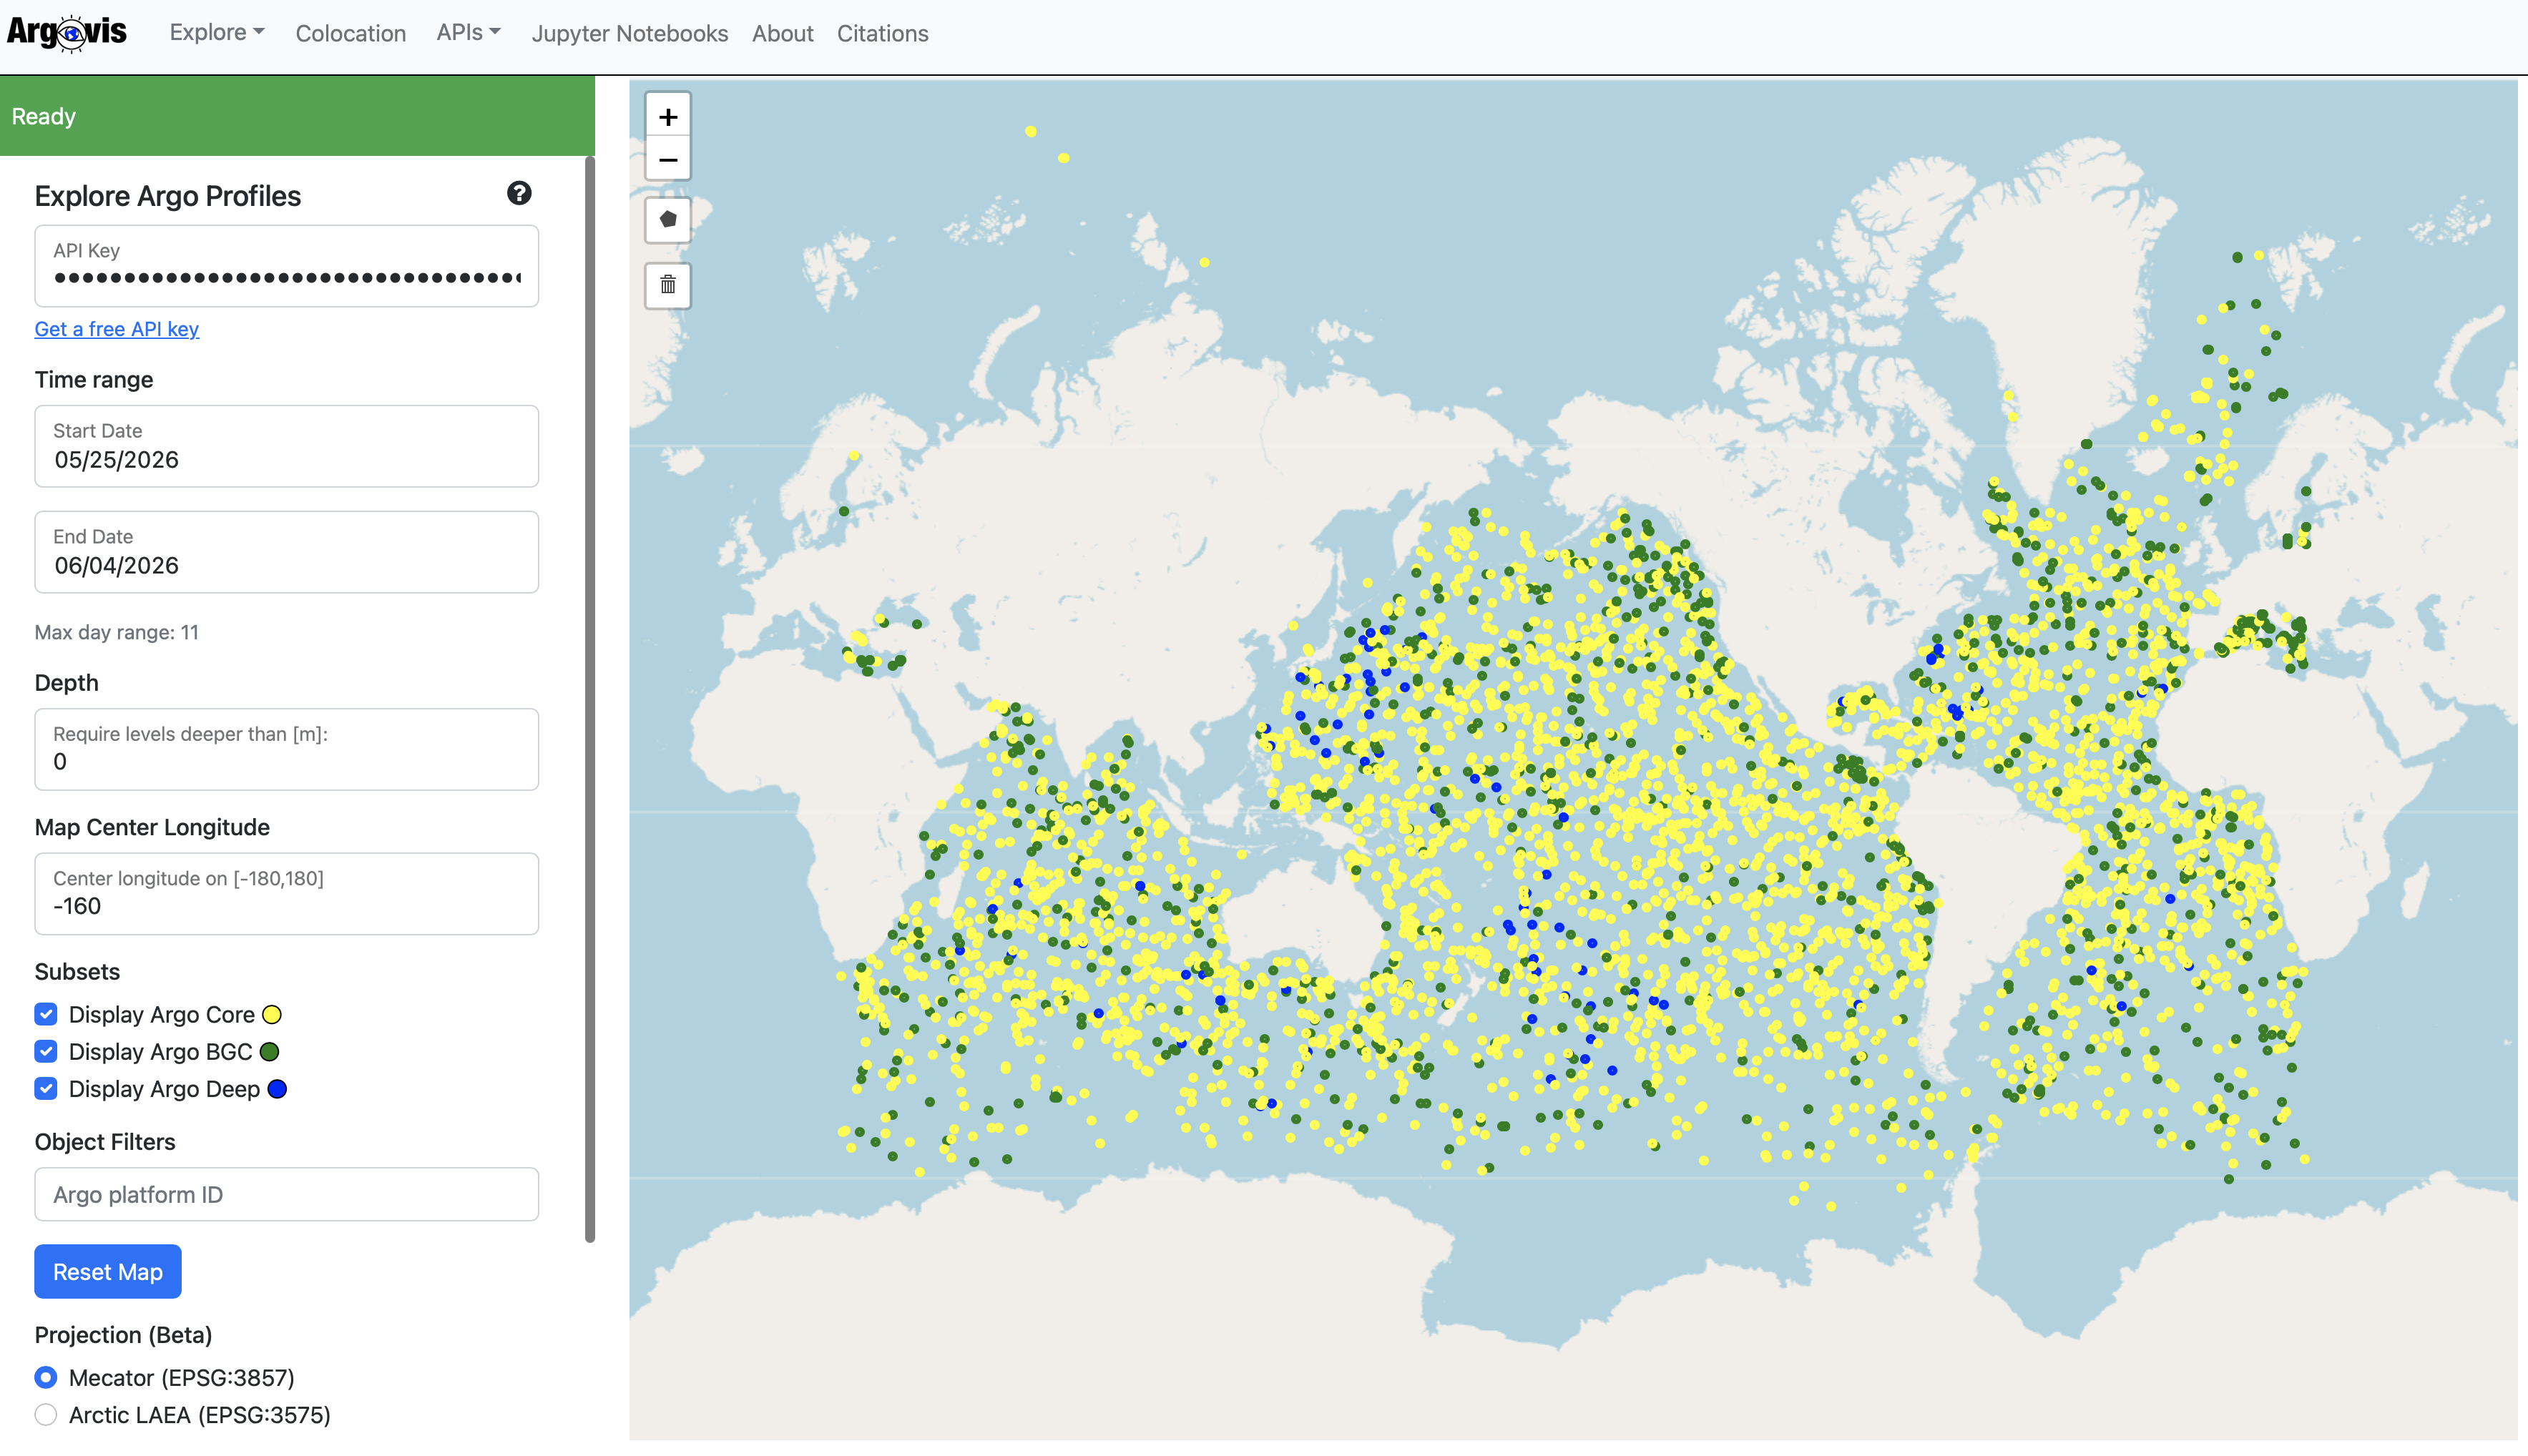

*Example of the Argovis interface - use this to identify your five float IDs.*

## Setup: configuration

✏️ **Student Work — Float Configuration**

Replace the placeholder IDs below with the profile IDs of the three floats you identified above.

In [3]:
# MODIFY HERE
# Edit the lines below. Replace each placeholder (XXXX_YYY) with a real profile ID.

BASIN_1 = 'Pacific Ocean'   # Change to your chosen basin

FLOAT_IDS_1 = [
    'XXXX_YYY',    # Float 1: Mid-latitudes  (30°N–50°N)
    'XXXX_YYY',    # Float 2: Tropics  (20°S–20°N)
    'XXXX_YYY',    # Float 3: Southern Ocean  (south of 50°S)
]

FLOAT_IDS_1 = [
    '4903411_087',    # Float 1: Mid-latitudes (34.5°N)
    '5905572_070',    # Float 2: Tropics (4.5°S)
    '5902452_294',    # Float 3: Southern Ocean (56.7°S)
]

# Colors are fixed: red = mid-latitudes, blue = tropics, green = Southern Ocean
COLORS = ['#e41a1c', '#377eb8', '#4daf4a']

In [4]:
# ── Query data — run, do not modify ──────────────────────────────────────────
platform_profiles_1 = query_floats(FLOAT_IDS_1, apikey=APIKEY)

Fetched 3/3 profiles:
  ✓  4903411_087             lat = +34.49°   lon = -162.33°
  ✓  5905572_070             lat =  -4.49°   lon = -163.21°
  ✓  5902452_294             lat = -56.70°   lon = -162.00°


In [5]:
# ── Compute derived variables — run, do not modify ───────────────────────────
compute_derived(platform_profiles_1)

✓ Derived properties computed for all profiles.


###  Visualization - Float Locations

The map below shows where your three floats are located. Verify that they span from mid-latitudes to the Southern Ocean and are roughly aligned in longitude, so that **latitude** is the main variable you are comparing across profiles.

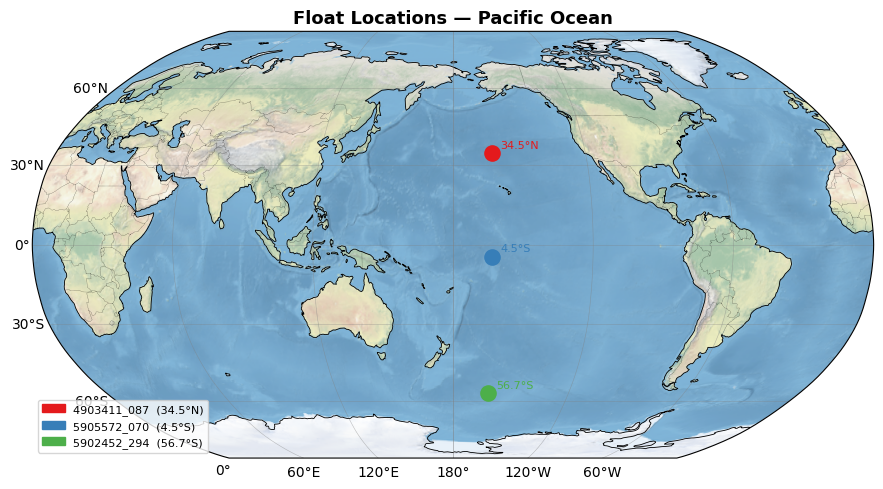

In [6]:
# ── Map of float locations — run, do not modify ──────────────────────────────
plot_float_map(platform_profiles_1, COLORS, label=BASIN_1)

###  Visualization - Temperature, Salinity, and Potential Density Profiles

The three panels below show the full vertical profile for each float:

- **Left — Temperature (°C):** the near-isothermal layer near the surface is the mixed layer; below it, temperature drops through the thermocline
- **Middle — Salinity (psu):** note any near-surface salinity gradients, especially in the Southern Ocean (meltwater) and tropics (rainfall)
- **Right — Potential Density (kg/m³):** the mixed layer appears as a nearly constant layer at the top; density increases sharply below it

Adjust `max_depth` in the code cell to zoom in on the upper ocean. Use these panels to answer **Step 2**.

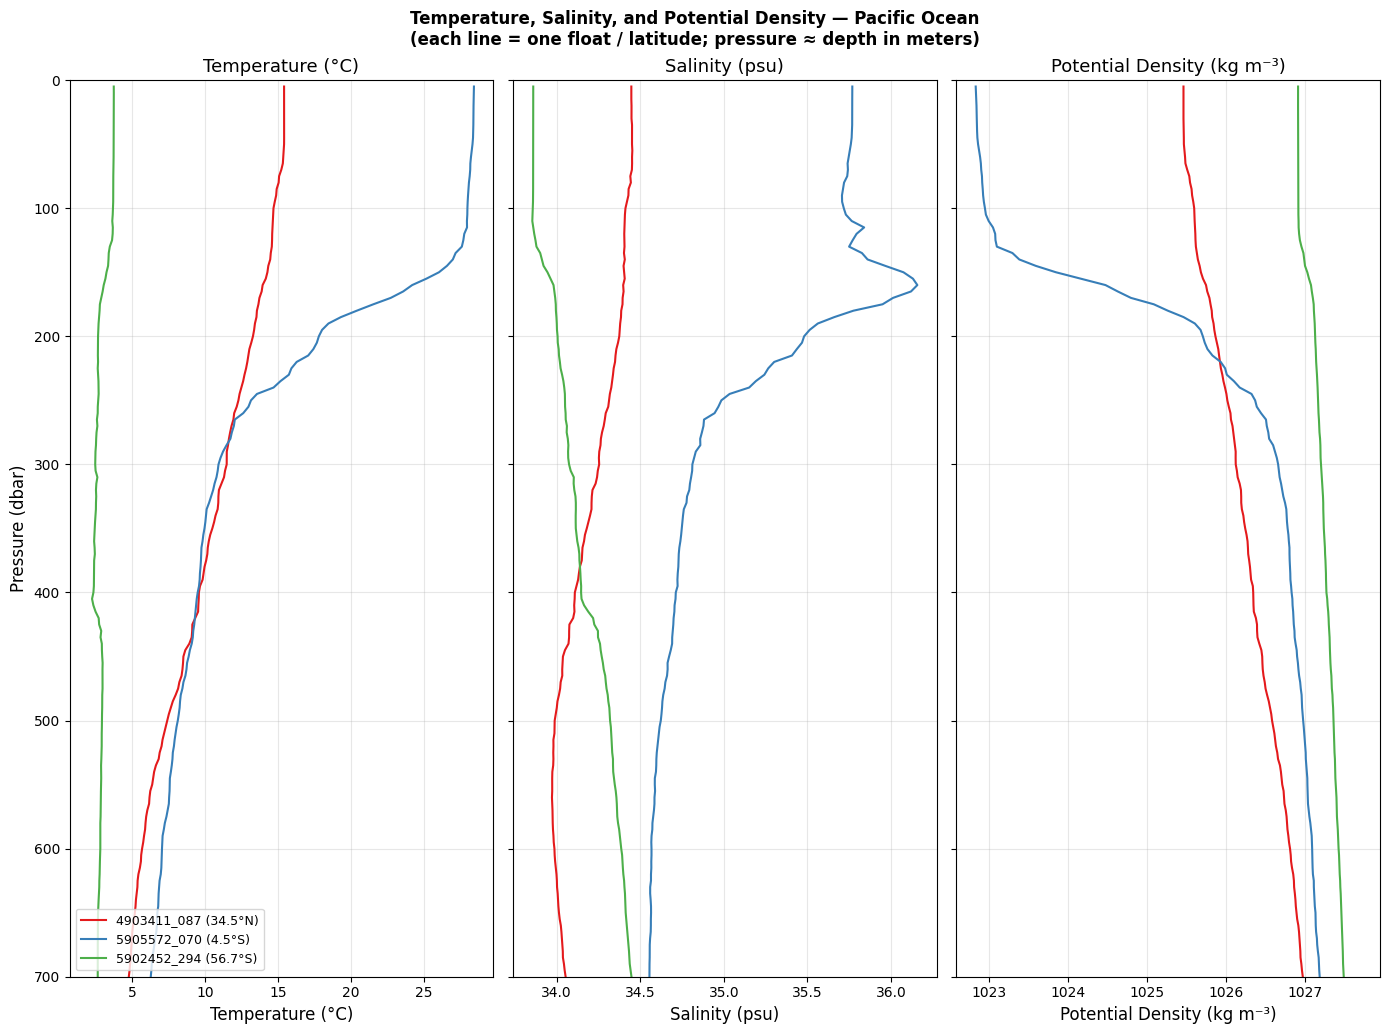

In [7]:
# ── T / S / PD profiles — run, do not modify ─────────────────────────────────
# Decrease max_depth (e.g. to 200) to zoom in on the upper ocean
max_depth = 700

plot_profiles(platform_profiles_1, COLORS, max_depth=max_depth, label=BASIN_1)

## Step 2 — Identify the mixed layer depth visually

✏️ **Student Work — MLD Visual Estimate**

Study the three panels above and fill in your estimates below.

---

**Q1 — Where is MLD$_T$?**
In the **Temperature panel** (left), the mixed layer is the near-vertical segment at the top where temperature is nearly constant. Below the mixed layer, temperature decreases — that transition marks MLD$_T$.


✏️ **Student Work — Q1: Temperature MLD Estimate**

*Estimate the depth (dbar) where temperature first starts to drop for each float:*
- Float 1 (Mid-latitudes):    MLD$_T$ ≈ _____ dbar
- Float 2 (Tropics):          MLD$_T$ ≈ _____ dbar
- Float 3 (Southern Ocean):   MLD$_T$ ≈ _____ dbar

*Double-click to edit this cell and fill in the blanks.*

✏️ **Student Work — Q2: Potential Density MLD Estimate**

**Q2 — Where is MLD$_{PD}$?**
In the **Potential Density panel** (right), the mixed layer is where density is nearly constant near the surface. Below it, density increases with depth.

*Estimate the depth where density starts to increase for each float:*
- Float 1 (Mid-latitudes):    MLD$_{PD}$ ≈ _____ dbar
- Float 2 (Tropics):          MLD$_{PD}$ ≈ _____ dbar
- Float 3 (Southern Ocean):   MLD$_{PD}$ ≈ _____ dbar

*Double-click to edit this cell and fill in the blanks.*

✏️ **Student Work — Q3: Salinity and MLD Differences**

**Q3 — Are MLD$_T$ and MLD$_{PD}$ different?**
Look at the **Salinity panel** (middle). Where salinity changes sharply near the surface, it can create density gradients that temperature alone would not reveal. Do you see such salinity gradients at any of your locations?

*Double-click to edit this cell and write your answer.*

✏️ **Student Work — Enter MLD Estimates**

Using your visual estimates from Q1 and Q2 above, enter your MLD values in the cell below.
Replace each `None` with a number in dbar (e.g. `None` → `45`).

In [8]:
# MODIFY HERE
# --- STUDENT WORK: replace each None with your estimated MLD in dbar ---

profiles_with_MLD_1 = [
    {'id': FLOAT_IDS_1[0], 'MLD_T': None, 'MLD_PD': None},  # Float 1: Mid-latitudes
    {'id': FLOAT_IDS_1[1], 'MLD_T': None, 'MLD_PD': None},  # Float 2: Tropics
    {'id': FLOAT_IDS_1[2], 'MLD_T': None, 'MLD_PD': None},  # Float 3: Southern Ocean
]

In [9]:
# ── STUDENT INPUT ─────────────────────────────────────────────────────────
# Enter your MLD estimates (in dbar) from the profiles above.
# Replace each None with a number, e.g.:   None  →  45

profiles_with_MLD_1 = [
    {'id': FLOAT_IDS_1[0], 'MLD_T': 72, 'MLD_PD': 68},
    {'id': FLOAT_IDS_1[1], 'MLD_T': 62, 'MLD_PD': 52},
    {'id': FLOAT_IDS_1[2], 'MLD_T': 128, 'MLD_PD': 128},
]

> **Check:** Run the cell below to plot your MLD markers on the profiles. Make sure each marker sits at the depth where the profile starts to change — adjust your estimates above if needed and re-run.

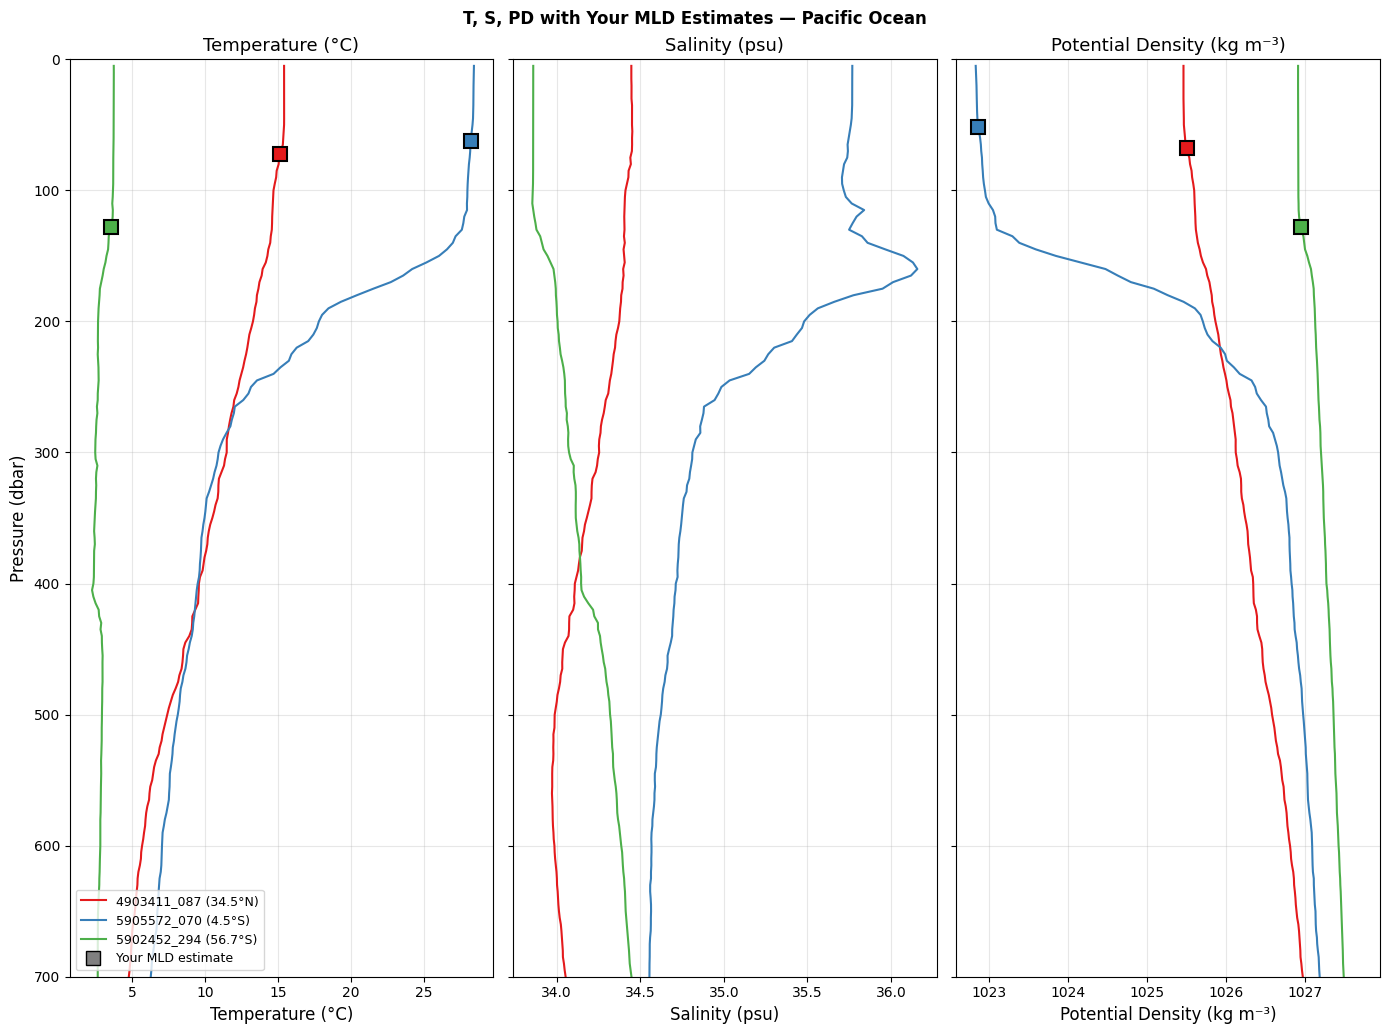

In [10]:
# ── Profiles with MLD markers — run, do not modify ───────────────────────────
plot_tspd_with_mld(platform_profiles_1, profiles_with_MLD_1,
                    COLORS, max_depth=max_depth, label=BASIN_1)

### MLD Summary Table

The table below collects your MLD estimates alongside each float's ID and latitude. Use it to compare MLD$_T$ and MLD$_{PD}$ across your three floats at a glance — and to check whether the two estimates agree or diverge for each location.

In [11]:
# ── Summary table — run, do not modify ───────────────────────────────────────
print_mld_table(platform_profiles_1, profiles_with_MLD_1, label=BASIN_1)



── MLD Summary: Pacific Ocean ──


,Float ID,Latitude,Your MLD_T (dbar),Your MLD_PD (dbar)
0,4903411_087,34.5°N,72,68
1,5905572_070,4.5°S,62,52
2,5902452_294,56.7°S,128,128


## Step 3 — Discussion: why do MLD$_T$ and MLD$_{PD}$ differ?

Answer the following for **each of your three floats**.

## ✏️ Student Work — Question 1: Float 1 — Mid-Latitudes / Subtropics

> Compare MLD$_T$ and MLD$_{PD}$ at this location.
> In subtropical regions, evaporation often exceeds precipitation, making the surface saltier.
> How would this affect the relationship between temperature-based and density-based MLD?

*Double-click to edit this cell and write your answer.*

## ✏️ Student Work — Question 2: Float 2 — Tropics

> In the tropics, heavy rainfall can create a layer of fresher water near the surface — a *salinity-stratified barrier layer*.
> Do you see evidence of a barrier layer in your profiles (i.e., MLD$_{PD}$ shallower than MLD$_T$)?
> What would the presence of a barrier layer mean for heat exchange between the ocean and atmosphere?

*Double-click to edit this cell and write your answer.*

## ✏️ Student Work — Question 3: Float 3 — Southern Ocean

> Are MLD$_T$ and MLD$_{PD}$ similar or different here?
> Look at the salinity profile. Is there a noticeable salinity gradient near the surface?
> If MLD$_{PD}$ is shallower than MLD$_T$, what does that imply about the role of salinity in creating the density stratification here?
> *(Hint: fresh meltwater from sea ice lowers surface salinity, which can create a shallow density stratification even within an isothermal layer.)*

*Double-click to edit this cell and write your answer.*

## ✏️ Student Work — Question 4: Why Potential Density Is a Better MLD Indicator

Why is **potential density** a more complete indicator of mixed layer depth than temperature alone?

*Double-click to edit this cell and write your answer.*

### Visualization - MLD vs. Latitude

The plot below shows your MLD$_T$ and MLD$_{PD}$ estimates as a function of latitude for your three floats. Look for the overall trend: does the mixed layer deepen or shoal as you move from the tropics toward higher latitudes?

Use this plot to answer **Step 4**.

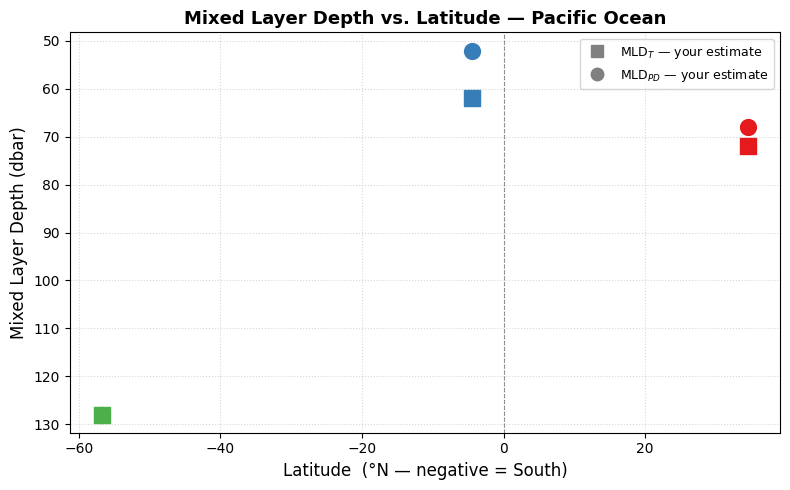

In [12]:
# ── MLD vs. Latitude — run, do not modify ────────────────────────────────────
plot_mld_vs_latitude(platform_profiles_1, profiles_with_MLD_1,
                      COLORS, label=BASIN_1)

## Step 4 — Interpreting MLD vs. latitude

## ✏️ Student Work — Question 5: MLD Latitudinal Pattern

Is the mixed layer deeper in the mid-latitudes, the tropics, or the Southern Ocean? Describe the overall pattern.

*Double-click to edit this cell and write your answer.*

## ✏️ Student Work — Question 6: Physical Drivers of MLD Variation

What physical processes drive these differences? Think about wind stress, buoyancy fluxes, and seasonal vs. permanent stratification.

*Double-click to edit this cell and write your answer.*

## ✏️ Student Work — Question 7: Southern Ocean and Deep MLD Locations

Why is the Southern Ocean mixed layer typically among the deepest in the world? What other places on Earth would you expect to have a deep MLD? Consider the role of strong winds, weak stratification, and seasonal convection.

*Double-click to edit this cell and write your answer.*

---
## Part 2 — A Second Ocean Basin

> **📄 Before you continue:** Save a record of your Part 1 work now (e.g. **File → Print Preview**, or **File → Save and Export Notebook As → PDF/HTML**). The cells below will overwrite `FLOAT_IDS_1`, your MLD estimates, and all of the plots above, so this is your only chance to keep a copy of Part 1.

## ✏️ Student Work — Question 8: Repeat Analysis for a Second Basin

Repeat the entire analysis for a **different ocean basin**.
- If you used the **Pacific** in Part 1 → use the **Atlantic** now (and vice versa).

Go back to the **Setup: configuration** cell (the `# MODIFY HERE` cell at the top of Part 1) and:
1. Change `BASIN_1` to your new basin name (e.g. `'Atlantic Ocean'`)
2. Replace all three float IDs in `FLOAT_IDS_1` with new floats at similar latitudes
3. Run all cells from the **Setup: configuration** cell downward

Do the mixed layer depths look different between the two basins at similar latitudes?

*Double-click to edit this cell and write your answer.*